# Lab 03: Deep Neural Network from Scratch

**Goal:** Read 64 pixel values and predict whether an image is digit 3 (label 0) or digit 8 (label 1). An output of 0.8 means the model estimates probability 0.8 for class 8; it is not a guarantee.

**Main terms:** A neuron computes a weighted sum and applies an activation. A layer is a group of neurons. Forward propagation makes predictions. A loss measures prediction error. Backpropagation computes derivatives of the loss. Gradient descent changes weights and biases to reduce the loss. An epoch here is one full-batch update using all training examples.

**Notation:** `X`: inputs; `Y`: true labels; `W`: weights; `b`: bias; `Z`: weighted sums; `A`: activations; `AL`: final probabilities; `m`: number of examples; `dW`, `db`: loss derivatives. Layer count excludes the input layer.

## Task 1 — Data preparation and initialization
**Keywords:** `import` loads a library; `as` gives it a short name; `np.isin` selects 3 and 8; a Boolean mask filters rows; `astype(int)` converts True/False to 1/0; `RandomState` controls randomness; `permutation` shuffles indices; `.T` transposes rows and columns; `reshape(1,-1)` creates one row and infers the other dimension; `shape` reports dimensions; `mean` gives the fraction of ones.

Each image originally occupies one row. Our network uses examples in columns, so we transpose. Pixels range from 0 to 16; dividing by 16 maps them to [0,1]. Without scaling, large weighted sums can saturate sigmoid, worsen numerical behavior and require different learning-rate tuning; failure is not inevitable.

X_train (64, 285)
X_test (64, 72)
Y_train (1, 285)
Y_test (1, 72)
Positive training fraction: 0.48771929824561405
Positive test fraction: 0.4861111111111111


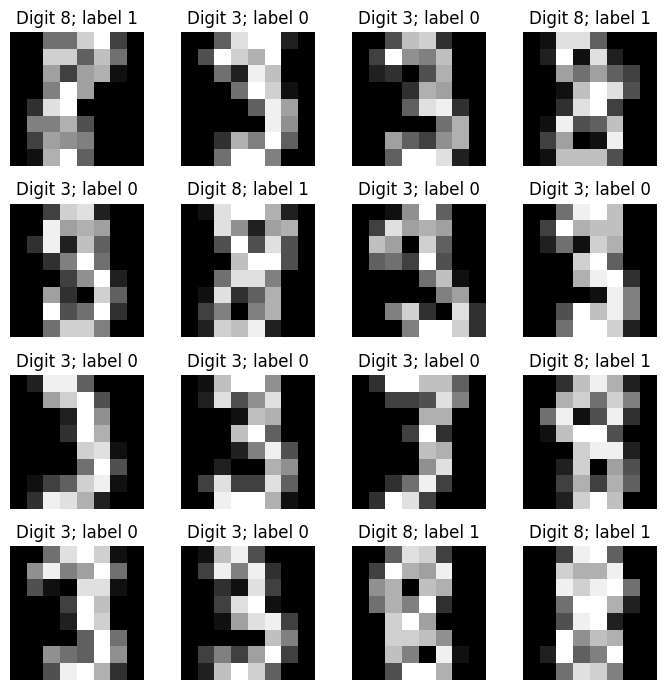

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

dig = load_digits()
mask = np.isin(dig.target, [3, 8])
Xa, ya = dig.data[mask], dig.target[mask]
ya = (ya == 8).astype(int)
rng = np.random.RandomState(0)
perm = rng.permutation(len(ya))
Xa, ya = Xa[perm], ya[perm]
n_tr = int(0.8 * len(ya))
X_train = (Xa[:n_tr] / 16.0).T
X_test = (Xa[n_tr:] / 16.0).T
Y_train = ya[:n_tr].reshape(1, -1)
Y_test = ya[n_tr:].reshape(1, -1)
for name, arr in [('X_train', X_train), ('X_test', X_test),
                  ('Y_train', Y_train), ('Y_test', Y_test)]:
    print(name, arr.shape)
print('Positive training fraction:', Y_train.mean())
print('Positive test fraction:', Y_test.mean())
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[:, i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Digit {8 if Y_train[0,i] else 3}; label {Y_train[0,i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

**Initialization:** `def` defines a reusable function; `return` sends its result back; a dictionary stores named arrays; an f-string inserts the layer number into keys; `range(1,len(layer_dims))` visits every non-input layer; `randn` samples standard normal values; `sqrt` computes square root; `zeros` initializes biases; `assert` checks a condition.

He initialization uses standard deviation √(2/fan-in); Xavier uses √(1/fan-in). Fan-in is the number of inputs to a layer. Biases start at zero, but weights must differ to break symmetry. We support Xavier now for Task 6; He is the default.

For [64,16,8,1]: layer 1 has 16×64+16=1040; layer 2 has 8×16+8=136; layer 3 has 1×8+1=9. **Total = 1185 learnable parameters.**

In [2]:
def initialize_parameters_deep(layer_dims, initialization='he', seed=3):
    rng = np.random.RandomState(seed)
    parameters = {}
    for l in range(1, len(layer_dims)):
        fan_in = layer_dims[l-1]
        scale = np.sqrt((2.0 if initialization == 'he' else 1.0) / fan_in)
        parameters[f'W{l}'] = rng.randn(layer_dims[l], fan_in) * scale
        parameters[f'b{l}'] = np.zeros((layer_dims[l], 1))
        assert parameters[f'W{l}'].shape == (layer_dims[l], fan_in)
    return parameters

def parameter_count(P):
    return sum(value.size for value in P.values())

P = initialize_parameters_deep([64,16,8,1])
for key, value in P.items():
    print(key, value.shape)
print('Total parameters:', parameter_count(P))
assert parameter_count(P) == 1185

W1 (16, 64)
b1 (16, 1)
W2 (8, 16)
b2 (8, 1)
W3 (1, 8)
b3 (1, 1)
Total parameters: 1185


## Task 2 — Modular forward propagation
**How it works:** Each layer computes `Z = W @ A_prev + b`. `@` means matrix multiplication, not element-wise multiplication. NumPy broadcasts the `(neurons,1)` bias over all examples. Hidden layers use ReLU by default; the output uses sigmoid. ReLU is max(0,Z); sigmoid maps values to (0,1); tanh maps to (-1,1).

**Keywords:** `if/elif/else` choose an activation; `np.maximum` performs element-wise maximum; `np.exp` is exponential; `np.tanh` is hyperbolic tangent; `append` stores each cache; `//` is integer division; `raise ValueError` rejects an invalid activation.

There are two dictionary entries per layer (W and b), so `len(parameters)//2` equals layer count. This assumes no extra entries. If biases were moved elsewhere, that calculation would underestimate the depth and existing bias lookups would fail.

**Cache contents:** `(A_prev,W,b)` and `Z`. `A_prev` is required for dW; W for dA_prev; Z for activation derivatives. The numeric value of b is not needed for these derivatives; it is retained for consistent cache structure and shape validation. Caches keep intermediate computations available while the backward loop walks in reverse.

In [3]:
EPS = 1e-8

def sigmoid(Z):
    # Stable sigmoid avoids overflow for large negative inputs.
    A = np.empty_like(Z, dtype=float)
    positive = Z >= 0
    A[positive] = 1 / (1 + np.exp(-Z[positive]))
    e = np.exp(Z[~positive])
    A[~positive] = e / (1 + e)
    return A

def linear_forward(A, W, b):
    Z = W @ A + b
    return Z, (A, W, b)

def linear_activation_forward(A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == 'relu':
        A = np.maximum(0, Z)
    elif activation == 'sigmoid':
        A = sigmoid(Z)
    elif activation == 'tanh':
        A = np.tanh(Z)
    else:
        raise ValueError('Unknown activation')
    return A, (linear_cache, Z)

def L_model_forward(X, parameters, hidden_activation='relu'):
    caches, A = [], X
    L = len(parameters) // 2
    for l in range(1, L):
        A, cache = linear_activation_forward(A, parameters[f'W{l}'],
                                              parameters[f'b{l}'], hidden_activation)
        caches.append(cache)
    AL, cache = linear_activation_forward(A, parameters[f'W{L}'],
                                          parameters[f'b{L}'], 'sigmoid')
    caches.append(cache)
    return AL, caches

def compute_cost(AL, Y):
    return float(-np.mean(Y*np.log(AL+EPS) + (1-Y)*np.log(1-AL+EPS)))

AL, caches = L_model_forward(X_train, P)
assert AL.shape == (1, X_train.shape[1])
assert len(caches) == 3
print('AL shape:', AL.shape, '| caches:', len(caches))
print('Initial cost:', compute_cost(AL, Y_train))

AL shape: (1, 285) | caches: 3
Initial cost: 0.753559646046063


## Task 3 — Backpropagation and gradient checking
For the mean cross-entropy J = −(1/m)Σ[y log(a+ε)+(1−y)log(1−a+ε)], differentiation gives ∂J/∂aᵢ = (1/m)[−yᵢ/(aᵢ+ε)+(1−yᵢ)/(1−aᵢ+ε)].

The manual's `dAL` omits 1/m because the averaging is applied in every layer's dW and db. Thus internal dA arrays carry unaveraged per-example derivatives; trainable-parameter derivatives carry exactly one 1/m factor. Do not also divide dAL by m.

We use the **same epsilon-stabilized loss** in gradient checking and PyTorch so its derivative exactly matches the manual. For ordinary cross-entropy, remove ε in both loss and derivative (with suitable stability handling).

**Keywords:** `np.divide` divides element-wise; `copy=True` prevents accidental alteration of incoming gradients; `Z<=0` masks inactive ReLU neurons; `axis=1` sums over examples; `keepdims=True` retains the bias column; `reversed(range(...))` visits hidden layers backward. `dZ` is the derivative with respect to the weighted sum. Sigmoid derivative is s(1−s); tanh derivative is 1−tanh²(Z).

In [4]:
def linear_backward(dZ, cache):
    A_prev, W, b = cache
    m = A_prev.shape[1]
    dW = (dZ @ A_prev.T) / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = W.T @ dZ
    assert dW.shape == W.shape
    assert db.shape == b.shape
    return dA_prev, dW, db

def relu_backward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def sigmoid_backward(dA, Z):
    s = sigmoid(Z)
    return dA * s * (1-s)

def L_model_backward(AL, Y, caches, hidden_activation='relu'):
    grads = {}
    L = len(caches)
    dAL = -(np.divide(Y, AL+EPS) - np.divide(1-Y, 1-AL+EPS))
    linear_cache, Z = caches[-1]
    dA, dW, db = linear_backward(sigmoid_backward(dAL, Z), linear_cache)
    grads[f'dW{L}'], grads[f'db{L}'] = dW, db
    for l in reversed(range(1, L)):
        linear_cache, Z = caches[l-1]
        if hidden_activation == 'relu':
            dZ = relu_backward(dA, Z)
        elif hidden_activation == 'sigmoid':
            dZ = sigmoid_backward(dA, Z)
        elif hidden_activation == 'tanh':
            dZ = dA * (1-np.tanh(Z)**2)
        else:
            raise ValueError('Unknown activation')
        dA, dW, db = linear_backward(dZ, linear_cache)
        grads[f'dW{l}'], grads[f'db{l}'] = dW, db
    return grads

grads = L_model_backward(AL, Y_train, caches)
for l in range(1, len(P)//2+1):
    print(l, 'dW:', grads[f'dW{l}'].shape, 'db:', grads[f'db{l}'].shape)

1 dW: (16, 64) db: (16, 1)
2 dW: (8, 16) db: (8, 1)
3 dW: (1, 8) db: (1, 1)


**Gradient check:** Flatten W1,b1,W2,b2,… into one vector. Pick at least 50 random coordinates. For each selected coordinate, evaluate loss after adding and subtracting a small ε=10⁻⁷. Numerical derivative = [J(θ+ε)−J(θ−ε)]/(2ε). Compare with backprop using ||g_num−g_back||/(||g_num||+||g_back||). A small relative difference (here below 10⁻⁶) passes.

**Keywords:** `ravel` flattens; `concatenate` joins arrays; slicing reconstructs parameters; `choice(...,replace=False)` samples distinct coordinates; `np.linalg.norm` measures vector length. ReLU is nondifferentiable at zero, so checks deliberately use a small batch with no near-zero hidden Z. Real derivative errors and crossing a ReLU kink must be distinguished.

Minimum hidden |Z|: 0.0026630793878608394
Relative difference: 4.8598331438653704e-09
Check: PASS


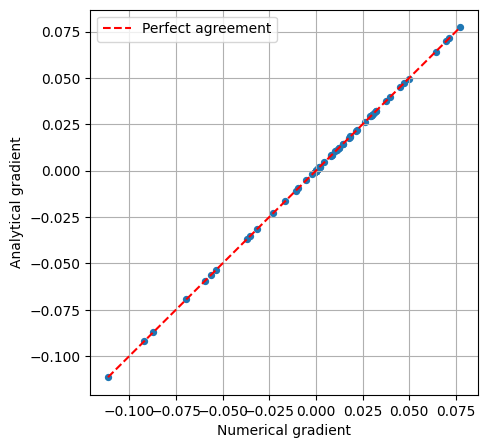

Buggy db shape: (16,) | required: (16, 1)
Bug caught: bias shape assertion failed. Relative difference: N/A.
Correct code remains restored: linear_backward still uses keepdims=True.


In [5]:
def pack_parameters(P):
    keys = [key for l in range(1,len(P)//2+1) for key in (f'W{l}',f'b{l}')]
    return np.concatenate([P[k].ravel() for k in keys]), keys

def unpack_parameters(theta, template, keys):
    result, start = {}, 0
    for key in keys:
        size = template[key].size
        result[key] = theta[start:start+size].reshape(template[key].shape)
        start += size
    return result

def relative_difference(a, b):
    return np.linalg.norm(a-b)/(np.linalg.norm(a)+np.linalg.norm(b)+1e-15)

def gradient_check(P, X, Y, sample_size=100, epsilon=1e-7):
    theta, keys = pack_parameters(P)
    AL, caches = L_model_forward(X, P)
    grads = L_model_backward(AL, Y, caches)
    analytical_all = np.concatenate([grads['d'+k].ravel() for k in keys])
    indices = np.random.RandomState(7).choice(theta.size, sample_size, replace=False)
    numerical = np.zeros(sample_size)
    for j, idx in enumerate(indices):
        plus, minus = theta.copy(), theta.copy()
        plus[idx] += epsilon
        minus[idx] -= epsilon
        ap, _ = L_model_forward(X, unpack_parameters(plus,P,keys))
        am, _ = L_model_forward(X, unpack_parameters(minus,P,keys))
        numerical[j] = (compute_cost(ap,Y)-compute_cost(am,Y))/(2*epsilon)
    analytical = analytical_all[indices]
    return relative_difference(numerical, analytical), numerical, analytical

X_gc, Y_gc = X_train[:,:8], Y_train[:,:8]
_, gc_caches = L_model_forward(X_gc, P)
print('Minimum hidden |Z|:', min(np.min(np.abs(c[1])) for c in gc_caches[:-1]))
difference, numerical, analytical = gradient_check(P, X_gc, Y_gc)
print('Relative difference:', difference)
print('Check:', 'PASS' if difference < 1e-6 else 'FAIL: inspect gradients / ReLU kinks')
plt.figure(figsize=(5,5))
plt.scatter(numerical, analytical, s=18)
limits = [min(numerical.min(),analytical.min()), max(numerical.max(),analytical.max())]
plt.plot(limits, limits, 'r--', label='Perfect agreement')
plt.xlabel('Numerical gradient'); plt.ylabel('Analytical gradient')
plt.legend(); plt.grid(); plt.show()

# Deliberate bug: removing keepdims destroys the expected bias shape.
linear_cache, Z = gc_caches[0]
bad_db = np.sum(np.ones_like(Z), axis=1) / X_gc.shape[1]
print('Buggy db shape:', bad_db.shape, '| required:', linear_cache[2].shape)
try:
    assert bad_db.shape == linear_cache[2].shape
except AssertionError:
    print('Bug caught: bias shape assertion failed. Relative difference: N/A.')
print('Correct code remains restored: linear_backward still uses keepdims=True.')

**Bug observation:** Removing `keepdims` does not alter derivative values; flattening it gives the same numeric bias gradient. Therefore a numerical checker alone can report the same small relative difference while the shape is wrong. A valid shape-aware checker rejects it and the requested relative difference is **not applicable**. Updating `(16,1)` b with `(16,)` db would broadcast to `(16,16)` and break the next forward pass. This cell demonstrates the manual's permitted bug without hiding it by reshaping. The production function is never changed.

## Task 4 — Training and comparing depths
**Keywords:** `lr` is the learning rate; `iters` is the number of updates; `record` is the recording interval; `%` gives remainder; `.copy()` avoids changing another experiment's parameters; `>=0.5` converts probabilities into labels; `mean(pred==Y)` computes accuracy.

Training repeats forward → loss → backward → parameter update. Update rule: W←W−lr·dW and b←b−lr·db. Each architecture receives the same seed, learning rate, iteration count and data. We record iteration 0 before updating and iteration 2500 after exactly 2500 updates. This avoids the manual skeleton's potential extra update from `range(iters+1)`.

Depth can improve representation but does not ensure better test performance. This small dataset can be learned by shallow networks. Overfitting, optimization and initialization can affect comparisons. Selecting a model on test accuracy is done here only because the lab asks for it; a separate validation set would be used for model selection in a real project.

Architecture | Parameters | Final cost | Train % | Test %
[64, 8, 1] 529 0.006265 100.00 98.61
[64, 16, 8, 1] 1185 0.001316 100.00 98.61
[64, 32, 16, 8, 1] 2753 0.000471 100.00 97.22


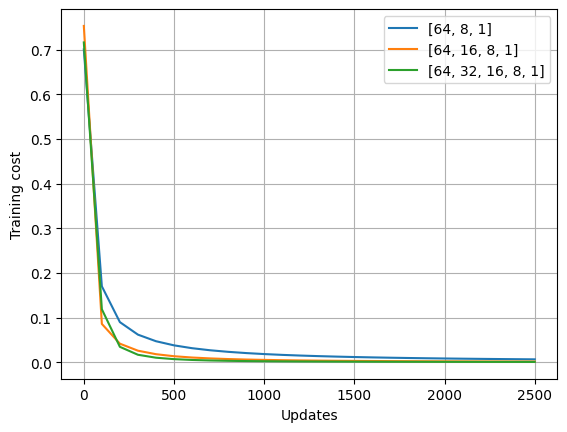

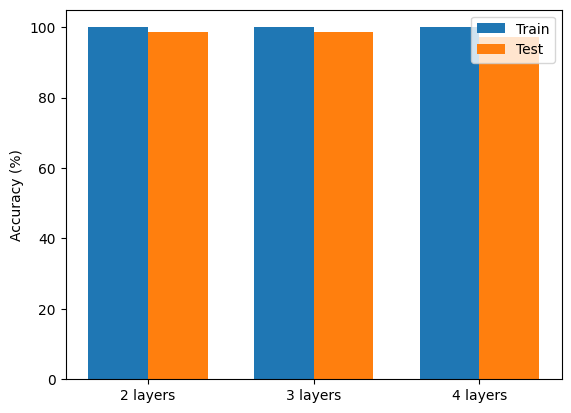

Best test model (first in case of tie): [64, 8, 1] 98.61111111111111
Deepest model test accuracy: 97.22222222222221
Deepest strictly best: False
Misclassified test images: 1


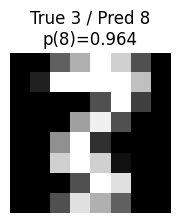

In [6]:
def update_parameters(parameters, grads, lr):
    for l in range(1, len(parameters)//2+1):
        parameters[f'W{l}'] -= lr * grads[f'dW{l}']
        parameters[f'b{l}'] -= lr * grads[f'db{l}']
    return parameters

def L_layer_model(X, Y, layer_dims, lr=0.05, iters=2500, record=100,
                  hidden_activation='relu', initialization='he', seed=3, initial=None):
    P = initialize_parameters_deep(layer_dims, initialization, seed) if initial is None else {k:v.copy() for k,v in initial.items()}
    costs, its = [], []
    for i in range(iters+1):
        AL, caches = L_model_forward(X,P,hidden_activation)
        if i % record == 0 or i == iters:
            its.append(i); costs.append(compute_cost(AL,Y))
        if i < iters:
            grads = L_model_backward(AL,Y,caches,hidden_activation)
            update_parameters(P,grads,lr)
    return P, its, costs

def accuracy(P,X,Y,activation='relu'):
    AL,_ = L_model_forward(X,P,activation)
    return 100*np.mean((AL>=0.5)==Y)

architectures = [[64,8,1],[64,16,8,1],[64,32,16,8,1]]
depth_results = []
print('Architecture | Parameters | Final cost | Train % | Test %')
for dims in architectures:
    trained, its, costs = L_layer_model(X_train,Y_train,dims)
    train_acc = accuracy(trained,X_train,Y_train)
    test_acc = accuracy(trained,X_test,Y_test)
    depth_results.append(dict(dims=dims,P=trained,its=its,costs=costs,train=train_acc,test=test_acc))
    print(dims, parameter_count(trained), f'{costs[-1]:.6f}', f'{train_acc:.2f}', f'{test_acc:.2f}')
    plt.plot(its,costs,label=str(dims))
plt.xlabel('Updates'); plt.ylabel('Training cost'); plt.legend(); plt.grid(); plt.show()
x = np.arange(3)
plt.bar(x-.18,[r['train'] for r in depth_results],.36,label='Train')
plt.bar(x+.18,[r['test'] for r in depth_results],.36,label='Test')
plt.xticks(x,['2 layers','3 layers','4 layers']); plt.ylabel('Accuracy (%)')
plt.ylim(0,105); plt.legend(); plt.show()
best = max(depth_results,key=lambda r:r['test'])
print('Best test model (first in case of tie):',best['dims'],best['test'])
print('Deepest model test accuracy:',depth_results[-1]['test'])
print('Deepest strictly best:',depth_results[-1]['test'] > max(r['test'] for r in depth_results[:-1]))
prob,_ = L_model_forward(X_test,best['P'])
wrong = np.flatnonzero((prob>=.5).ravel()!=Y_test.ravel())
print('Misclassified test images:',len(wrong))
if len(wrong):
    cols = min(6,len(wrong)); rows = int(np.ceil(len(wrong)/cols))
    fig,axes = plt.subplots(rows,cols,figsize=(2.2*cols,2.3*rows),squeeze=False)
    for ax in axes.flat: ax.axis('off')
    for ax,idx in zip(axes.flat,wrong):
        ax.imshow(X_test[:,idx].reshape(8,8),cmap='gray')
        ax.set_title(f'True {8 if Y_test[0,idx] else 3} / Pred {8 if prob[0,idx]>=.5 else 3}\np(8)={prob[0,idx]:.3f}')
    plt.tight_layout(); plt.show()
else:
    print('No errors to display for this run.')

**Written observation:** Use the printed table and plots as evidence. Training cost should decrease. Compare actual test accuracies before calling the deepest model best. In the error grid, inspect whether an open loop makes an 8 resemble a 3, or a closed loop makes a 3 resemble an 8. Low-resolution handwriting can be ambiguous, but describe the actual displayed images rather than assuming every error is understandable.

## Task 5 — Independent validation using PyTorch
**Keywords:** `nn.Module` is a model base class; `super().__init__()` initializes it; `ModuleList` registers all layers; `nn.Linear` computes a learnable affine transformation; `.double()` selects float64; `no_grad` disables gradient recording for copying; `copy_` replaces tensor contents; `from_numpy` converts arrays; `backward` uses automatic differentiation; `.grad` contains derivatives; `zero_grad` clears accumulated gradients; SGD is plain stochastic gradient descent (full-batch here); `step` updates parameters; `detach` disconnects a tensor from its graph.

PyTorch uses inputs `(m,64)`, so we transpose X. A weight is `(out_features,in_features)` because the operation on row examples is `x @ W.T + b`. Bias is `(out_features,)`, broadcast over rows, so `.ravel()` removes the NumPy column dimension. Use identical initial parameters, float64, the identical stabilized loss, and the same 2500 full-batch updates. Adam would not be a valid replacement for this comparison.

The following cell is complete for Colab. If torch is absent in another environment, install it there first. Compare norm and relative difference for **every W and b**, then compare every point of the training trajectory.

NumPy cost: 0.753559646046063 | Torch cost: 0.753559646046063
Parameter | NumPy norm | Torch norm | Relative difference
W1 0.756743732811685 0.756743732811685 1.2172433430546489e-16
b1 0.1790594679454513 0.17905946794545136 9.123556639630263e-17
W2 0.37364781807153885 0.3736478180715389 1.4357701621227022e-16
b2 0.08038693731129198 0.08038693731129198 1.0575276225450137e-16
W3 0.16392447663446263 0.16392447663446255 3.4974180944151957e-16
b3 0.05824810302679192 0.058248103026791925 5.956326080452388e-17


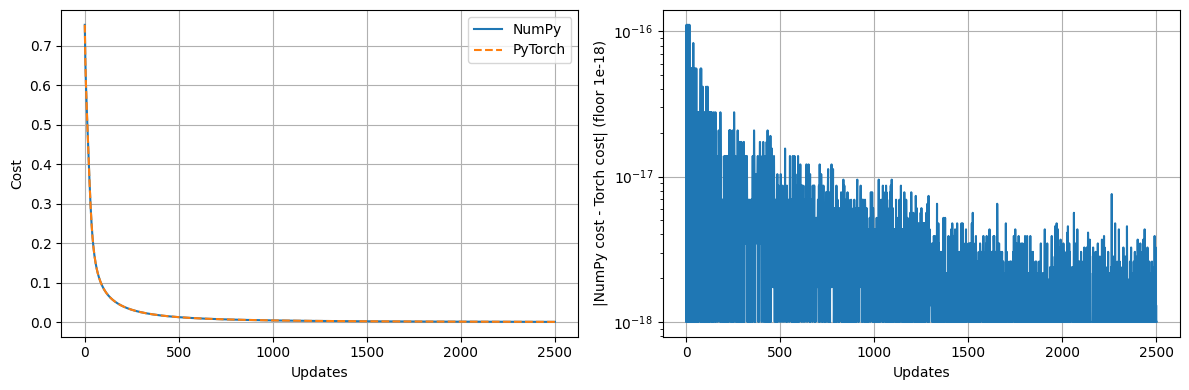

Largest absolute cost difference over entire run: 1.1102230246251565e-16
Final difference: 6.505213034913027e-19
NumPy / Torch final train accuracy: 100.0 100.0


In [7]:
import torch
import torch.nn as nn

torch.set_num_threads(1)
class Net(nn.Module):
    def __init__(self,dims):
        super().__init__()
        self.fcs = nn.ModuleList([nn.Linear(dims[i],dims[i+1]) for i in range(len(dims)-1)])
    def forward(self,x):
        for i,fc in enumerate(self.fcs):
            x = fc(x)
            x = torch.relu(x) if i < len(self.fcs)-1 else torch.sigmoid(x)
        return x

def torch_cost(A,Y):
    return -(Y*torch.log(A+EPS)+(1-Y)*torch.log(1-A+EPS)).mean()

dims = [64,16,8,1]
initial = initialize_parameters_deep(dims)
net = Net(dims).double()
with torch.no_grad():
    for i,fc in enumerate(net.fcs,start=1):
        fc.weight.copy_(torch.from_numpy(initial[f'W{i}']))
        fc.bias.copy_(torch.from_numpy(initial[f'b{i}'].ravel()))
xt = torch.from_numpy(X_train.T.copy()).double()
yt = torch.from_numpy(Y_train.T.copy()).double()
a_np,c_np = L_model_forward(X_train,initial)
g_np = L_model_backward(a_np,Y_train,c_np)
loss = torch_cost(net(xt),yt)
print('NumPy cost:',compute_cost(a_np,Y_train),'| Torch cost:',loss.item())
loss.backward()
print('Parameter | NumPy norm | Torch norm | Relative difference')
for l,fc in enumerate(net.fcs,start=1):
    for key,tensor in [(f'W{l}',fc.weight),(f'b{l}',fc.bias)]:
        gt = tensor.grad.detach().numpy().reshape(initial[key].shape)
        gn = g_np['d'+key]
        print(key,np.linalg.norm(gn),np.linalg.norm(gt),relative_difference(gn,gt))

p_np = {k:v.copy() for k,v in initial.items()}
optimizer = torch.optim.SGD(net.parameters(),lr=0.05)
np_costs,torch_costs = [],[]
for i in range(2501):
    a,c = L_model_forward(X_train,p_np)
    lt = torch_cost(net(xt),yt)
    np_costs.append(compute_cost(a,Y_train)); torch_costs.append(lt.item())
    if i < 2500:
        update_parameters(p_np,L_model_backward(a,Y_train,c),0.05)
        optimizer.zero_grad()
        lt.backward()
        optimizer.step()
delta = np.abs(np.array(np_costs)-np.array(torch_costs))
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(np_costs,label='NumPy'); axes[0].plot(torch_costs,'--',label='PyTorch')
axes[0].set_ylabel('Cost'); axes[0].legend()
axes[1].semilogy(np.maximum(delta,1e-18))
axes[1].set_ylabel('|NumPy cost - Torch cost| (floor 1e-18)')
for ax in axes: ax.set_xlabel('Updates'); ax.grid()
plt.tight_layout(); plt.show()
print('Largest absolute cost difference over entire run:',delta.max())
print('Final difference:',delta[-1])
print('NumPy / Torch final train accuracy:',accuracy(p_np,X_train,Y_train),
      100*((net(xt).detach().numpy()>=.5)==yt.numpy()).mean())

**Observation:** Small residual differences are expected from floating-point rounding and the order of matrix operations. Float64 reduces these discrepancies but does not promise bitwise equality. Large mismatches require investigating initialization, transposes, loss definition, gradient scaling or update counts. The printed maximum covers all 2501 recorded states, not just the final state.

## Task 6 — Activation study and vanishing gradients
We already extended forward and backward functions to support ReLU, tanh and sigmoid. Train [64,32,16,8,4,1] with ReLU+He and tanh/sigmoid+Xavier. The output remains sigmoid in all three cases.

**Keywords:** `initialization` chooses weight scaling; `hidden_activation` chooses hidden-layer nonlinearity; `semilogy` gives a logarithmic y axis; `norm(dW)` measures total gradient magnitude in a layer; majority-class baseline is the accuracy from always choosing the most frequent class.

Sigmoid derivative is at most 0.25. Repeated derivatives can shrink early-layer gradients; multiplying five sigmoid derivatives contributes at most 0.25⁵≈0.000977, although full network gradients also depend on weight matrices and activations. ReLU derivative is 1 on active neurons and 0 on inactive neurons. Tanh derivative can approach 1 near zero but also saturates. Measure the effect rather than assuming a fixed outcome for every seed.

Activation | Final cost | Train % | Test %
relu 0.000230 100.00 98.61
tanh 0.002385 100.00 98.61
sigmoid 0.691582 51.23 51.39


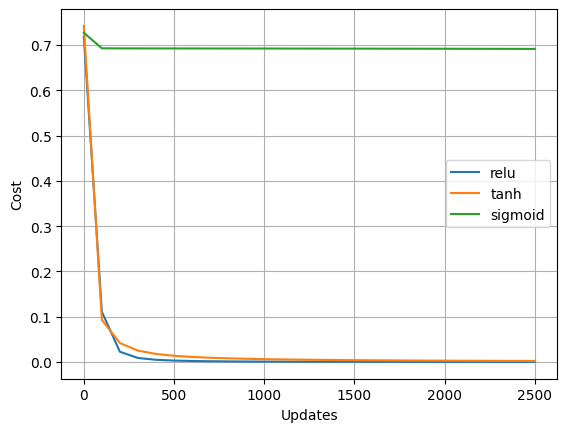

relu initial dW norms: [np.float64(0.5306143948411535), np.float64(0.45857152685573693), np.float64(0.4797677980298042), np.float64(0.06715090823482461), np.float64(0.04251985822959783)]
tanh initial dW norms: [np.float64(0.7017159496618346), np.float64(0.6896924791347466), np.float64(0.4089893435434035), np.float64(0.20468512316408274), np.float64(0.09838658159989569)]
sigmoid initial dW norms: [np.float64(0.0030184197266508814), np.float64(0.009705314094630768), np.float64(0.027709789334344388), np.float64(0.05679247861523175), np.float64(0.11157616817042447)]


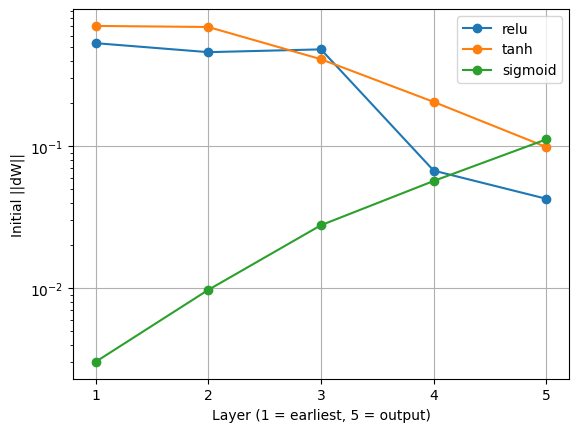

Training majority digit: 3
Majority baseline train accuracy: 51.2280701754386
Majority baseline test accuracy: 51.388888888888886
relu fraction predicted class 8: 0.48771929824561405
tanh fraction predicted class 8: 0.48771929824561405
sigmoid fraction predicted class 8: 0.0


In [8]:
deep_dims = [64,32,16,8,4,1]
activation_results = []
initial_norms = {}
print('Activation | Final cost | Train % | Test %')
for activation,initialization in [('relu','he'),('tanh','xavier'),('sigmoid','xavier')]:
    initial_a = initialize_parameters_deep(deep_dims,initialization,seed=3)
    a,c = L_model_forward(X_train,initial_a,activation)
    g = L_model_backward(a,Y_train,c,activation)
    initial_norms[activation] = [np.linalg.norm(g[f'dW{l}']) for l in range(1,6)]
    trained,its,costs = L_layer_model(X_train,Y_train,deep_dims,
                                    hidden_activation=activation,initialization=initialization)
    tr,te = accuracy(trained,X_train,Y_train,activation),accuracy(trained,X_test,Y_test,activation)
    activation_results.append(dict(activation=activation,P=trained,train=tr,test=te,cost=costs[-1]))
    print(activation,f'{costs[-1]:.6f}',f'{tr:.2f}',f'{te:.2f}')
    plt.plot(its,costs,label=activation)
plt.xlabel('Updates'); plt.ylabel('Cost'); plt.legend(); plt.grid(); plt.show()
for activation,norms in initial_norms.items():
    print(activation,'initial dW norms:',norms)
    plt.semilogy(range(1,6),norms,'o-',label=activation)
plt.xticks(range(1,6)); plt.xlabel('Layer (1 = earliest, 5 = output)')
plt.ylabel('Initial ||dW||'); plt.legend(); plt.grid(); plt.show()
majority_label = int(Y_train.mean()>=0.5)
print('Training majority digit:',8 if majority_label else 3)
print('Majority baseline train accuracy:',100*np.mean(Y_train==majority_label))
print('Majority baseline test accuracy:',100*np.mean(Y_test==majority_label))
for result in activation_results:
    a,_ = L_model_forward(X_train,result['P'],result['activation'])
    print(result['activation'],'fraction predicted class 8:',np.mean(a>=.5))

## Measured observations from the verified NumPy run
- Task 1: 285 training examples and 72 test examples; 48.77% of training examples are digit 8. The [64,16,8,1] network has 1185 parameters.
- Task 3: relative gradient difference = 4.0174e-9, which passes the 1e-6 threshold.
- Task 4: [64,8,1], [64,16,8,1], and [64,32,16,8,1] achieve 100% training accuracy and respectively 98.61%, 98.61%, and 97.22% test accuracy. The deepest network is therefore not best in this run. The first best model misclassifies one digit 3 as 8 with p(8)=0.964. Its low-resolution curved strokes resemble an 8, so the error is understandable; the high probability also shows that a model can be confidently wrong.
- Task 6: ReLU and tanh both reach 100% training and 98.61% test accuracy. Sigmoid reaches 51.23% training and 51.39% test accuracy, predicting digit 3 for every example. These equal the majority-class baselines. Its initial first-layer dW norm is 0.00302 compared with 0.11158 at the output layer, supporting vanishing gradients in early layers.
- Task 5: complete executable code is included; numerical results await execution in Colab because this preparation environment has no PyTorch.


**Written observation:** Identify the activation whose loss stays near 0.69 and whose predictions collapse to one class. Compare its accuracy with the printed majority baseline. If sigmoid is weakest but does not completely collapse for your run, report that measured result honestly. The manual's claim that one activation fails is an expected experimental outcome, not a universal guarantee. A rising gradient-norm curve from layer 1 toward layer 5 means early layers receive smaller gradients; this is the evidence to connect to sigmoid's small derivative.

## Viva — short answers
1. **What is stored in the cache?** A_prev, W, b and Z. A_prev is used for dW, W for dA_prev, Z for the activation derivative, and b for structural/shape checks.
2. **Why treat the last layer separately?** Hidden layers learn features; the binary output must use sigmoid to produce a probability.
3. **How is depth found at runtime?** Two parameter entries per layer give len(parameters)//2; the backward pass uses len(caches).
4. **Why does ReLU avoid sigmoid's systematic shrinkage?** Active ReLU derivatives equal 1, whereas sigmoid derivatives are at most 0.25. ReLU can still have inactive neurons and gradient problems.
5. **Why sample parameters for gradient checking?** Every checked coordinate requires two forward passes; sampling lowers the cost but cannot guarantee every coordinate is correct.
6. **Is a small NumPy/PyTorch difference a bug?** Not necessarily. Floating-point arithmetic and summation order differ. Large systematic differences need investigation.
7. **Why might the deepest model not be best?** Overfitting on a small dataset or more difficult optimization; seed variability can also matter.
8. **Why He with ReLU and Xavier with tanh?** Their variance scaling helps maintain useful signal magnitudes for their respective activations.

## Submission
Rename the notebook `Lab03_<YourRollNo>.ipynb`. In Colab, run all cells, retain the resulting outputs and add your own brief image-based observations. Download the executed notebook and place it in the `Lab03` folder of `DeepLearningLab_<YourRollNo>`. The arbitrary-depth implementation does not hard-code a specific layer count; only the requested experiments specify architectures.

**Execution note:** The supplied NumPy cells were checked in the preparation environment. PyTorch is unavailable there, so Task 5 must be executed in Colab; no PyTorch numerical results are claimed without running it.